In [163]:
using Distributions
using StatsBase
using PythonPlot
using DataFrames
using Optim
using NLsolve
using Setfield
using CSV
include("simulations.jl")
include("estimators.jl")
include("models.jl")
include("rem_theory.jl")

FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

"/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

# setup

## Load data

In [164]:
# Read CSV file
data_raw = CSV.read("/Users/elevien/Downloads/data_processed.csv", DataFrame)

# Group and combine data with minimal operations
data = combine(groupby(data_raw, [:lineage, :cell]), 
               :time => first => :t_int, 
               :cell => first => :n,:gr => mean => :gr)

# Convert and normalize time in one step
data.t = convert(Vector{Float64}, data.t_int) ./ mean(diff(data[data.lineage .==1,:].t_int));

# Extract model paramaters

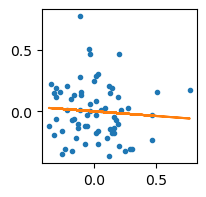

In [165]:
# for the AR1 model we need the CV of generation times and correlation coefficient
tau = diff(data[data.lineage .==8,:].t)
a = cov(tau[1:end-1],tau[2:end])/var(tau)
v = var(tau)
θAR1 = (σ=v,a = a)
fig, ax= subplots(figsize=(2,2))
ax.plot(tau[1:end-1].- mean(tau),tau[2:end].- mean(tau),".")
ax.plot(tau.- mean(tau),a*(tau.- mean(tau)))
fig

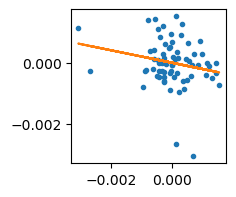

In [172]:
# for the AR1 model we need the CV of generation times and correlation coefficient
gr = data[data.lineage .==3,:].gr
agr = cov(gr[1:end-1],gr[2:end])/var(gr)
v = sqrt(var(gr))
θCSC = (σg=5*v,ag = a,σM = 0.1,aM = 1/1)


fig, ax= subplots(figsize=(2,2))
ax.plot(gr[1:end-1].- mean(gr),gr[2:end].- mean(gr),".")
ax.plot(gr.- mean(gr),agr*(gr.- mean(gr)))


fig

In [185]:
# scaling of AR1 model
dfAR1 = makelineage(AR1,[0.0,1.0],1260,θAR1,[:t,:gt])
dfAR1[:,:lineage] = ones(length(dfAR1.t));

# scaling of CSC model
dfCSC = makelineage(CSC,[0.0,1.0,1.0,1.0],1260,θCSC,[:t,:size,:gr,:gt])
dfCSC[:,:lineage] = ones(length(dfCSC.t));
dfCSC.t = convert(Vector{Float64},dfCSC.t) ./ mean(diff(dfCSC[dfCSC.lineage .==1,:].t));
dfCSC[:,:gt] = push!(diff(dfCSC.t),1)

1260-element Vector{Float64}:
 0.9983938735878648
 0.9946277971316109
 0.9962310949156077
 1.0007261684737347
 0.9992310687752957
 1.0041023235208781
 1.0060157408425567
 0.9949424200299788
 0.9987066209057716
 1.0011973681354185
 ⋮
 1.0064129751056043
 1.0022528343338308
 1.0029351372591009
 0.996272859052624
 0.9992476355096187
 1.0021728983567755
 0.9984032517627384
 0.9972518041645344
 1.0

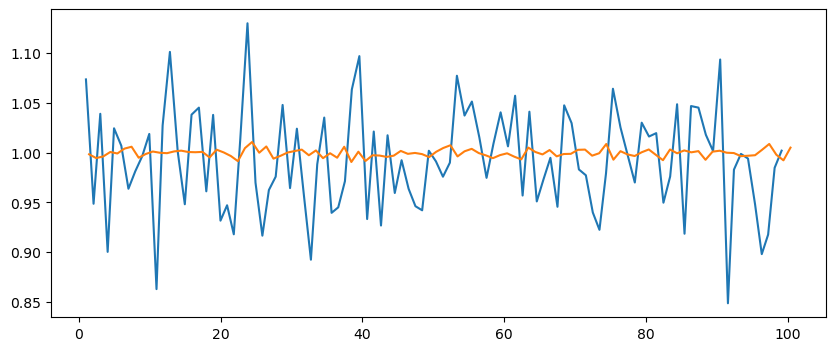

In [186]:
fig,ax = subplots(figsize=(10,4))
ax.plot(dfAR1.t[1:100],dfAR1.gt[1:100]);
ax.plot(dfCSC.t[1:100],dfCSC.gt[1:100]);
fig

# Plot estimate vs. alpha

In [187]:
# generate scaling data
scaling = scalingdata_FDE(data,collect(1:2:60))
scaling_AR1 = scalingdata_FDE(dfAR1,collect(1:2:60));
scaling_CSC = scalingdata_FDE(dfCSC,collect(1:2:60));

In [188]:
# now I'm going to get the n and M values for the previous figure to compare
M_fig3 = 100
alpha_fig3 = CSV.read("./output/alpha_FDE",DataFrame)[:,1]
n_fig3 = alpha_fig3 .^2 .* M_fig3 ./ 2;

sys:1: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


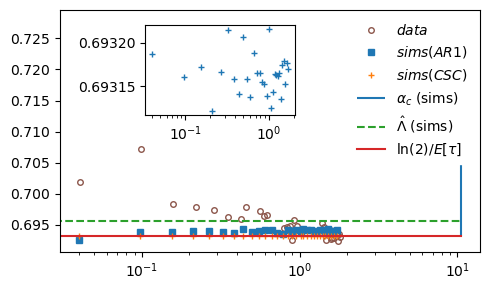

In [189]:



ms = 4
fig, ax= subplots(figsize=(5,3))

# ------------------------------------------------------------------------------------------
# INSET PLOT

axins = fig.add_axes([0.3, 0.6, 0.3, 0.3])
s = std(diff(data[1:20,:].t))
αc = βc/(log(2)*s) # our best approximation of αc

#axins.plot(scaling.α ,scaling.fde,"C5o",label=L"data",markersize=ms,fillstyle="none")
#axins.plot(scaling_AR1.α ,scaling_AR1.fde,"s",label=L"sims",markersize=ms)
axins.semilogx(scaling_sims.α ,scaling_CSC.fde,"+",label=L"sims (CSC)",markersize=ms)

Ltrue = 2log(2)/(1+sqrt(1-2log(2)*θ.σ^2))
# axins.plot([0,max(scaling.α ...)],ones(2) .*Ltrue,"--",label=L"$\hat{\Lambda}$ (sims)")

# axins.plot([0,max(scaling.α ...)] , log(2) ./ones(2)* 1 ,label=L"$\ln(2)/E[\tau]$")
# axins.set_xlabel(L"$\alpha$")
# axins.set_ylabel(L"$\hat{\Lambda}_{\rm FDE}$")
# axins.set_xlim([0,max(scaling.α ...)])

# ------------------------------------------------------------------------------------------
# MAIN PLOT 
ax.plot(scaling.α ,scaling.fde,"C5o",label=L"data",markersize=ms,fillstyle="none")

ax.semilogx(scaling_sims.α ,scaling_AR1.fde,"s",label=L"sims (AR1)",markersize=ms)
ax.semilogx(scaling_sims.α ,scaling_CSC.fde,"+",label=L"sims (CSC)",markersize=ms)
ax.vlines(αc,log(2),1.05*log(2),"C10",linestyle="-",label=L"$\alpha_c$ (sims)")
ax.plot([0,αc],ones(2) .*Ltrue,"--",label=L"$\hat{\Lambda}$ (sims)")

ax.plot([0,αc] , log(2) ./ones(2)* 1 ,label=L"$\ln(2)/E[\tau]$")
ax.legend(loc=1,facecolor="white",framealpha=1.0,edgecolor="w")

tight_layout()
savefig(FIG_PATH*"/data.pdf",bbox_inches="tight")
fig

In [7]:
fig, ax= subplots(figsize=(4,2))
ax.plot(scaling_sims.α ,scaling_sims.fde,"+-",label=L"$\hat{\Lambda}_{\rm FDE}$")
fig

UndefVarError: UndefVarError: `scaling_sims` not defined

\alpha  

# Check scaling of variance

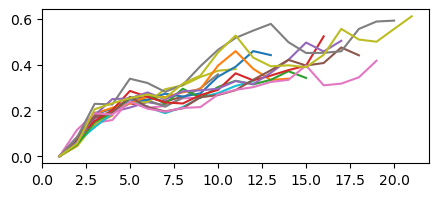

In [37]:
step = 500
data[:,:t_round] = round.(data.t / step) * step;

fig,ax = subplots(figsize=(5,2))

for g in 2:20
    # ------------------------------------------------------------
    Xg = grouplineages(data,g)
     
    v = combine(groupby(Xg,:n),:t => var => :v).v
    m = combine(groupby(Xg,:n),:t => mean => :m).m

    des = hcat(ones(length(m)),collect(1:length(m)))
    b = des\m
    y_fit = des*b 

    ax.plot(1:length(m),v,"-")
end
#
fig

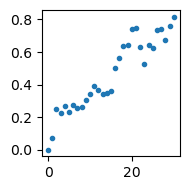

In [40]:
fig,ax = subplots(figsize=(2,2))
ax.plot(combine(groupby(grouplineages(data,30),:n),:t => var => :v).v,".")
tight_layout()
fig


It look slike the variance is not increasing linearly with time as we expect (show simulations in comparison)